In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage


In [28]:
# Configuración visual de los gráficos
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [29]:
# ==========================================
# 1. DESCARGAR Y EXPLORAR LOS DATOS

print("CARGANDO Y EXPLORANDO DATOS")
# 1.1 Leer el archivo CSV
df = pd.read_csv('/datasets/gym_churn_us.csv')


CARGANDO Y EXPLORANDO DATOS


In [30]:
# ==========================================================
# 2. LLEVAR A CABO EL ANÁLISIS EXPLORATORIO DE DATOS (EDA)
print("\n PASO 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)")

# 2.1 Observar características ausntes, valores promedio y desviación estándar
print("\n2.1.1 Conteo de valores ausentes por columna:")
print(df.isnull().sum())


 PASO 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

2.1.1 Conteo de valores ausentes por columna:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [31]:
print("\n2.1.2 Estadísticas descriptivas (Valores promedio y desviación estándar):")
print(df.describe().T)


2.1.2 Estadísticas descriptivas (Valores promedio y desviación estándar):
                                    count        mean        std        min  \
gender                             4000.0    0.510250   0.499957   0.000000   
Near_Location                      4000.0    0.845250   0.361711   0.000000   
Partner                            4000.0    0.486750   0.499887   0.000000   
Promo_friends                      4000.0    0.308500   0.461932   0.000000   
Phone                              4000.0    0.903500   0.295313   0.000000   
Contract_period                    4000.0    4.681250   4.549706   1.000000   
Group_visits                       4000.0    0.412250   0.492301   0.000000   
Age                                4000.0   29.184250   3.258367  18.000000   
Avg_additional_charges_total       4000.0  146.943728  96.355602   0.148205   
Month_to_end_contract              4000.0    4.322750   4.191297   1.000000   
Lifetime                           4000.0    3.724750   

In [32]:
# 2.2 Observar los valores medios de las características para los dos grupos (groupby)
print("\n2.2 Valores medios de las características según la cancelación (Churn):")
# 0 = Clientes que se quedan, 1 = Clientes que cancelan
print(df.groupby('Churn').mean().T)


2.2 Valores medios de las características según la cancelación (Churn):
Churn                                       0           1
gender                               0.510037    0.510839
Near_Location                        0.873086    0.768143
Partner                              0.534195    0.355325
Promo_friends                        0.353522    0.183789
Phone                                0.903709    0.902922
Contract_period                      5.747193    1.728558
Group_visits                         0.464103    0.268615
Age                                 29.976523   26.989632
Avg_additional_charges_total       158.445715  115.082899
Month_to_end_contract                5.283089    1.662582
Lifetime                             4.711807    0.990575
Avg_class_frequency_total            2.024876    1.474995
Avg_class_frequency_current_month    2.027882    1.044546


In [33]:
# 2.3 Trazar histogramas de barras y distribuciones de características para ambos grupos
print("\n2.3 Generando gráficos de distribuciones")


2.3 Generando gráficos de distribuciones


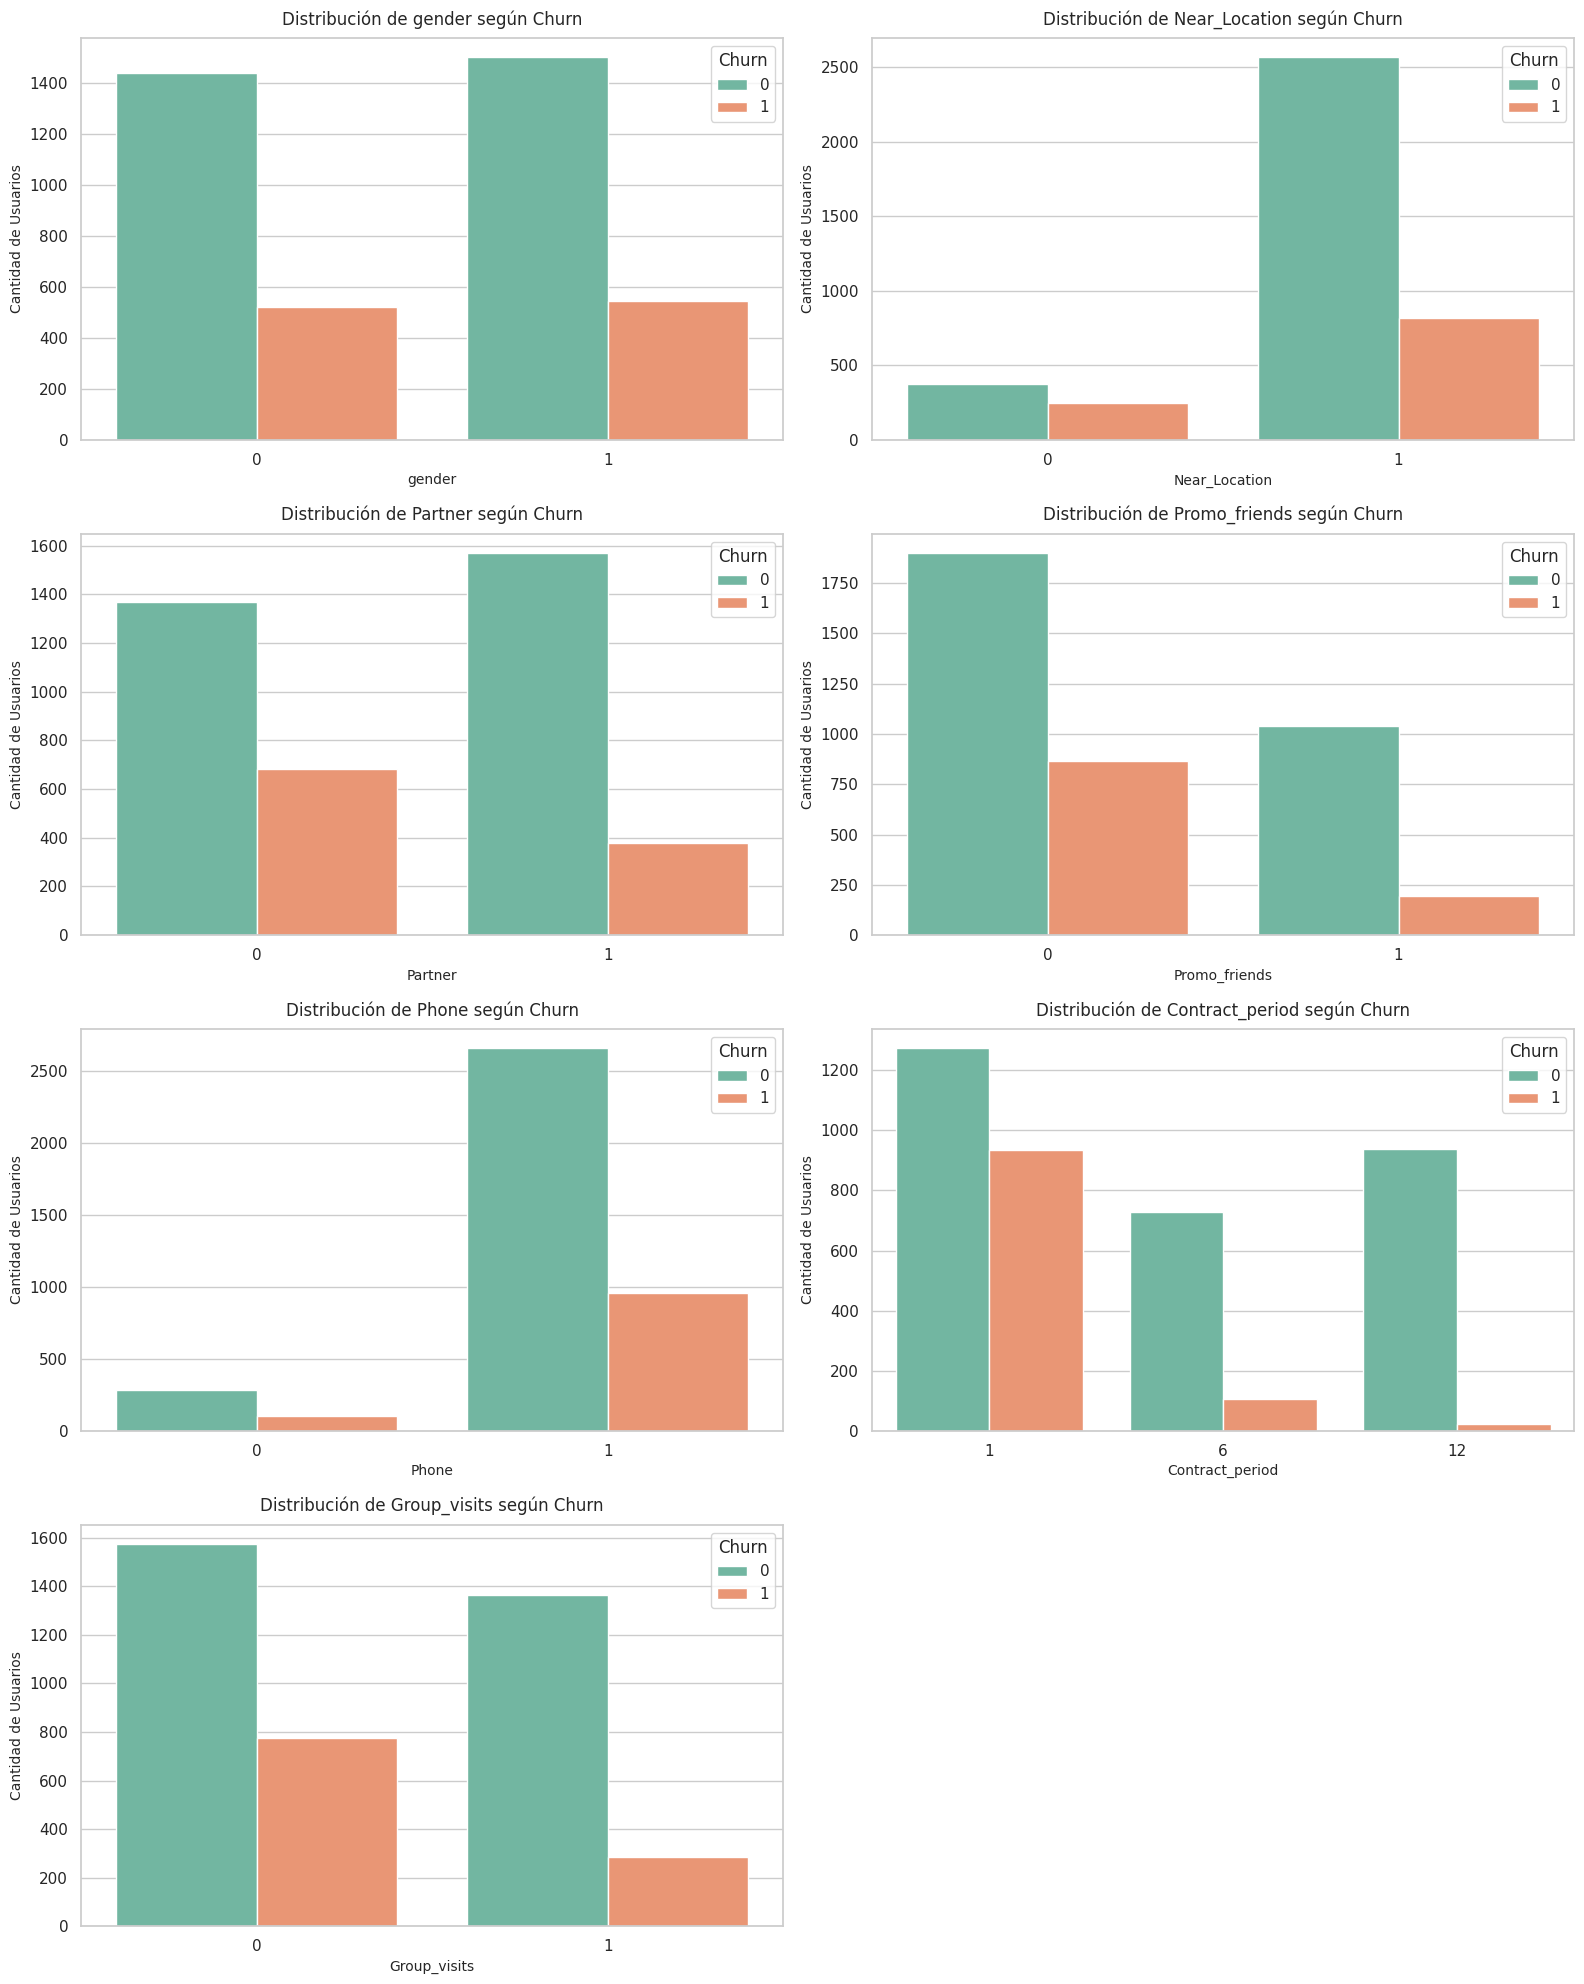

In [34]:
# Lista exacta de columnas categóricas en el dataset
categorical_features = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits']

# Creamos la cuadrícula de 4 filas y 2 columnas
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.ravel() # Aplana la matriz de gráficos a una lista 1D

# Llenamos cada cuadro con su respectivo gráfico
for i, col in enumerate(categorical_features):
    # Forzamos a Seaborn a dibujar explícitamente en el cuadro actual (ax=axes[i])
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    
    # Añadimos títulos y etiquetas personalizadas
    axes[i].set_title(f'Distribución de {col} según Churn', fontsize=12, pad=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Cantidad de Usuarios', fontsize=10)

# Eliminamos el octavo cuadro gris que queda vacío (ya que solo tenemos 7 variables)
fig.delaxes(axes[-1])

# Ajustamos los espacios para que no se encimen los textos y mostramos
plt.tight_layout()
plt.show()

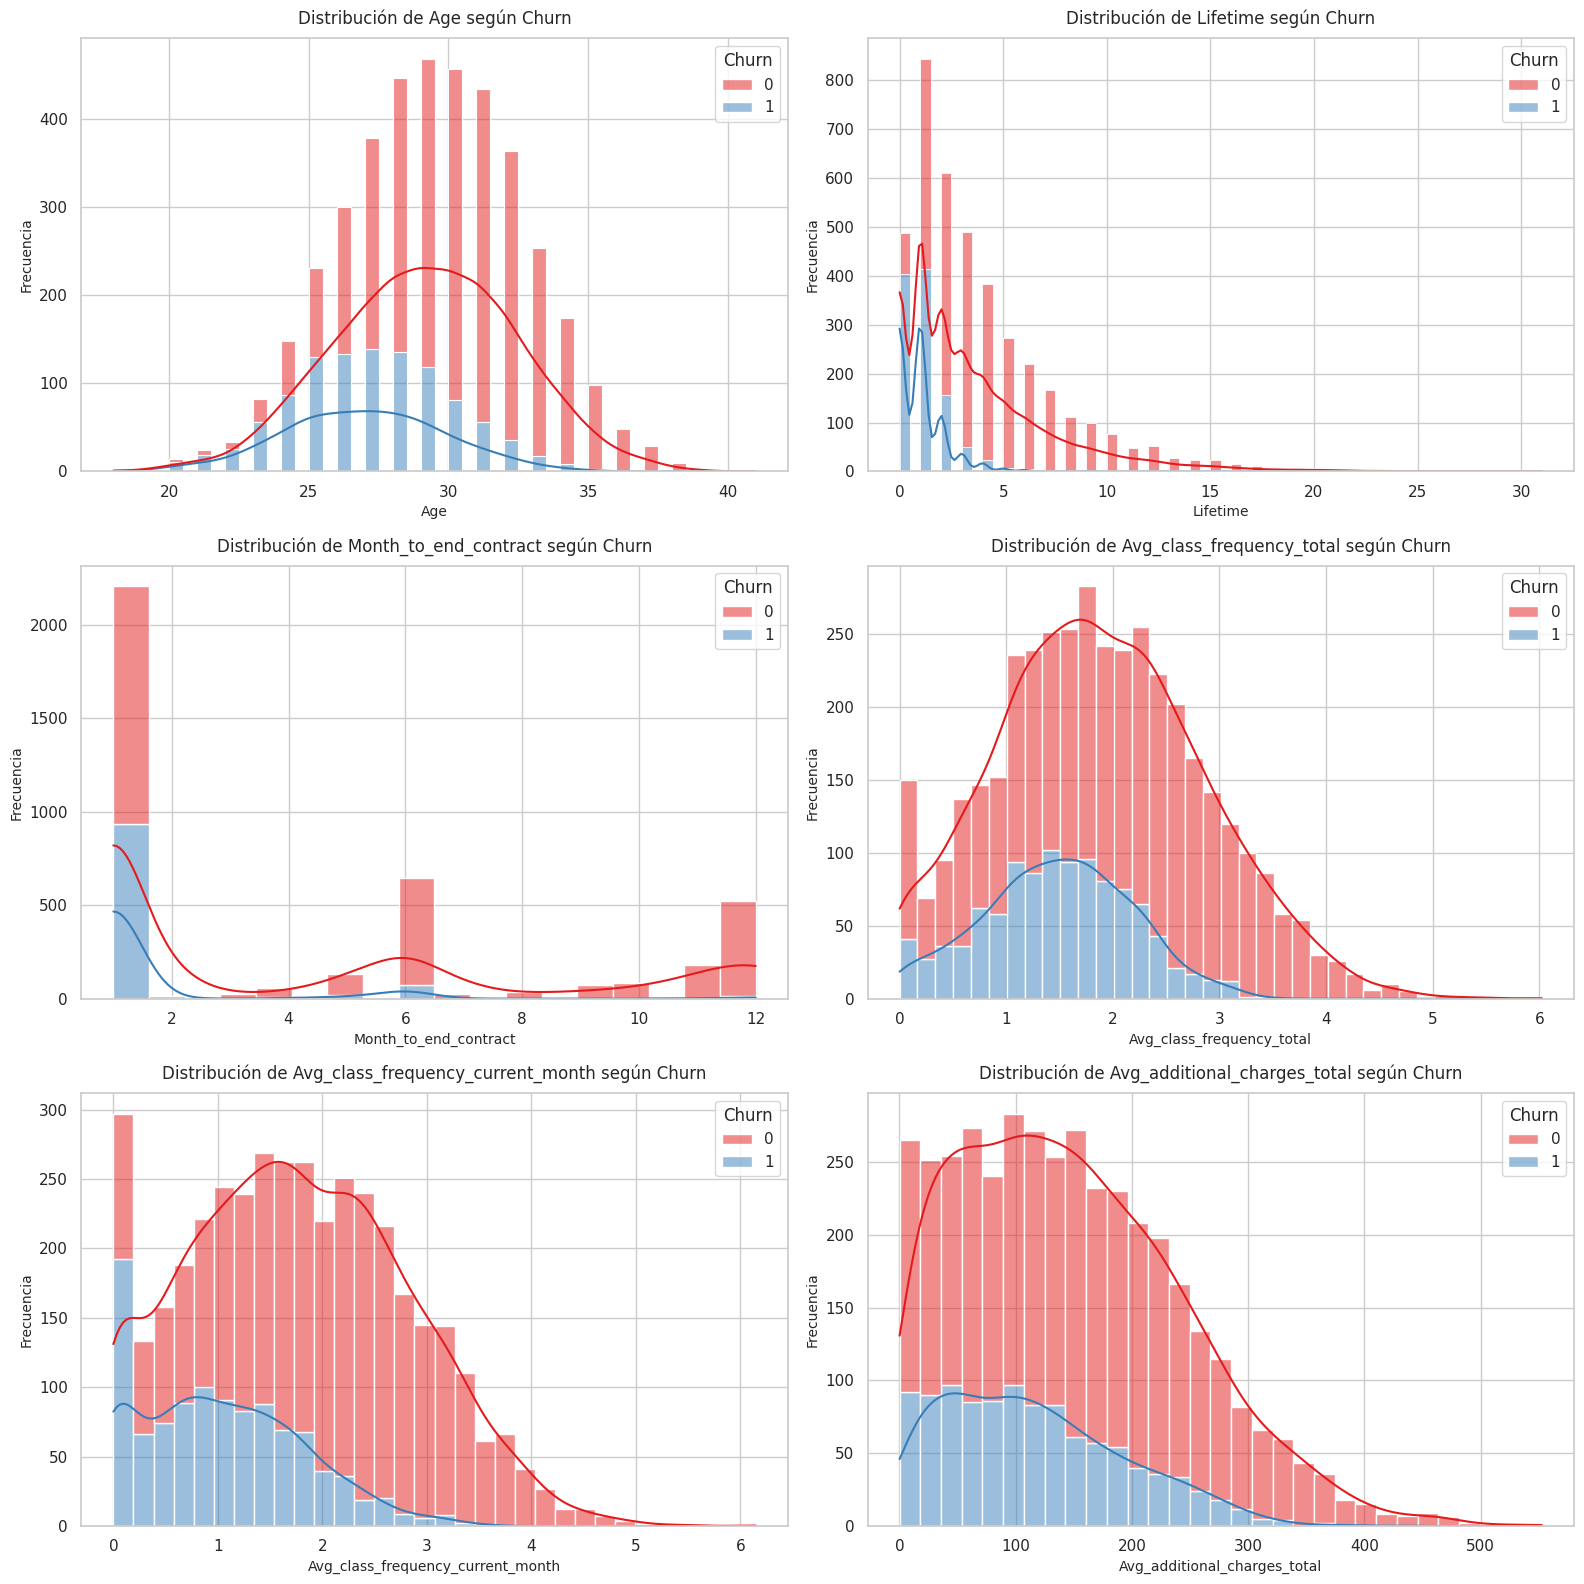

In [37]:
# Lista de columnas numéricas en el dataset
numeric_features = ['Age', 'Lifetime', 'Month_to_end_contract', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Avg_additional_charges_total']

# Creamos la cuadrícula de 3 filas y 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.ravel() # Aplana la matriz de gráficos a una lista 1D

# Llenamos cada cuadro con su respectivo histograma
for i, col in enumerate(numeric_features):
    # Dibujamos el histograma con curva de densidad (kde=True) en el cuadro actual
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i], palette='Set1', multiple='stack')
    
    # Añadimos títulos y etiquetas personalizadas
    axes[i].set_title(f'Distribución de {col} según Churn', fontsize=12, pad=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)

# Ajustamos los espacios para evitar solapamientos y mostramos los gráficos
plt.tight_layout()
plt.show()


2.4 Mostrando la matriz de correlación...


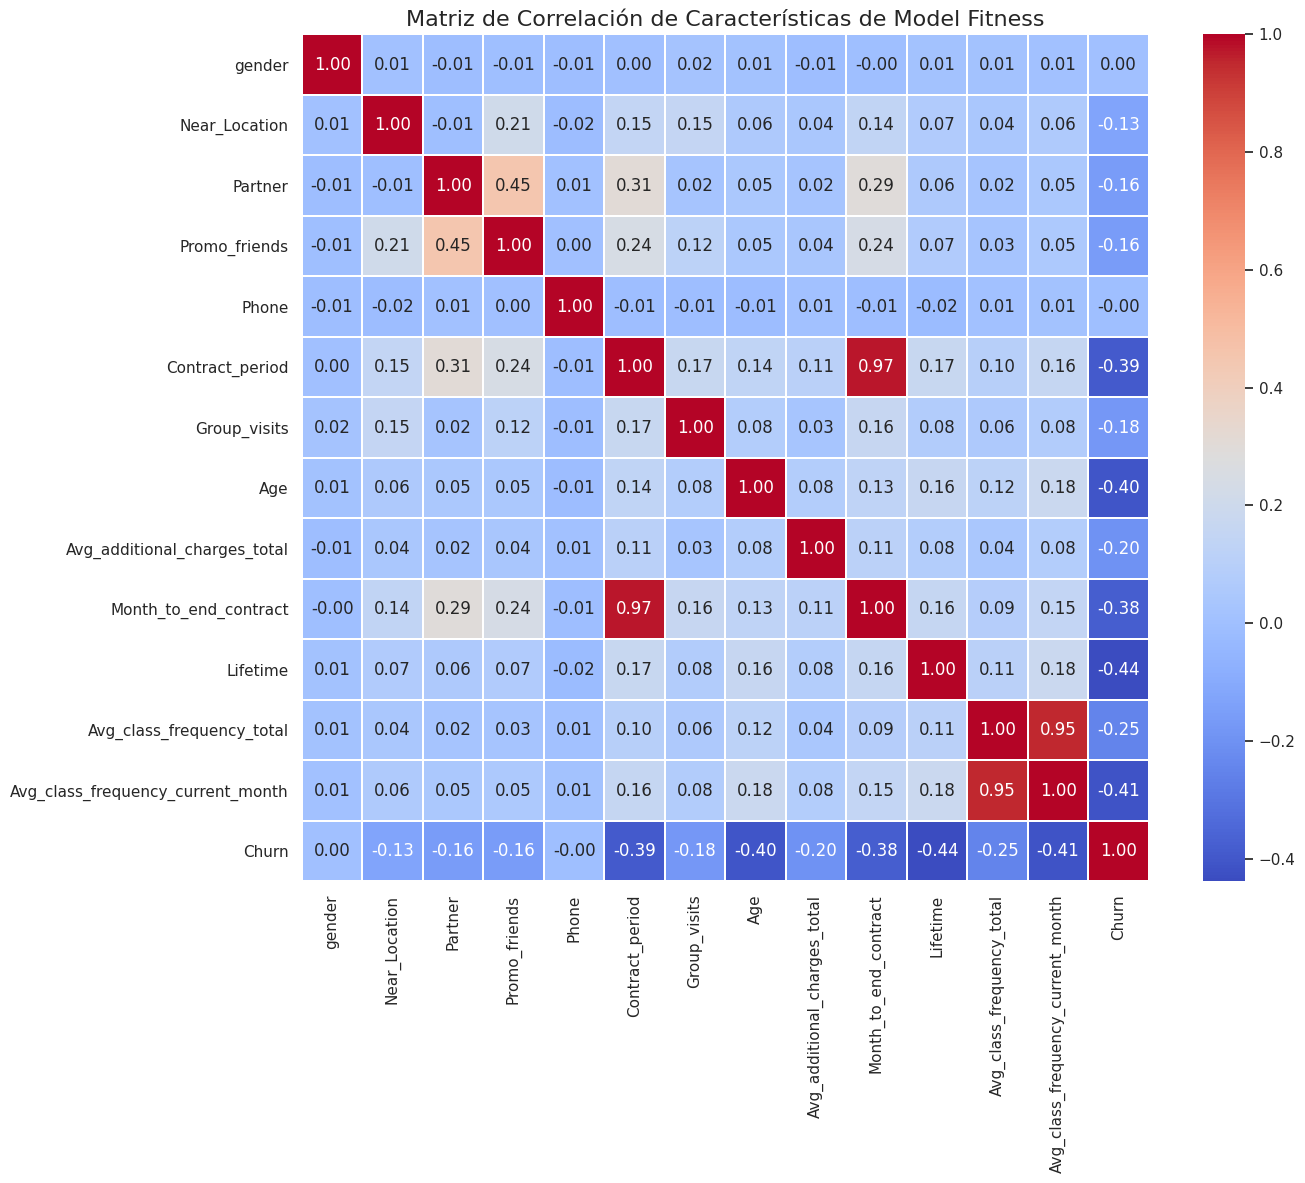

In [36]:
# 2.4 Crea una matriz de correlación y muétsrala
print("\n2.4 Mostrando la matriz de correlación...")
plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de Correlación de Características de Model Fitness', fontsize=16)
plt.show()

In [14]:
# ==========================================================
# 3. CONSTRUIR UN MODELO PARA PREDECIR LA CANCELACIÓN
# ==========================================================
print("\n--- PASO 3. CONSTRUYENDO MODELOS DE PREDICCIÓN ---")

# Divide los datos en características (X) y variable objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']


--- PASO 3. CONSTRUYENDO MODELOS DE PREDICCIÓN ---


In [15]:
# Divide los datos en conjuntos de entrenamiento y validación (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Estandariza los datos utilizando StandardScaler
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)
X_val_st = scaler.transform(X_val)

In [17]:
# Declrar los algoritmos indicando el parámetro random_state
lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

In [18]:
# Función para entrenar, predecir y evaluar la exactitud, precisión y recall
def evaluar_clasificador(model, X_tr, y_tr, X_v, y_v, nombre_modelo):
    model.fit(X_tr, y_tr)
    predicciones = model.predict(X_v)
    
    acc = accuracy_score(y_v, predicciones)
    prec = precision_score(y_v, predicciones)
    rec = recall_score(y_v, predicciones)
    
    print(f"\nMétricas de Validación para {nombre_modelo}:")
    print(f"Accuracy (Exactitud):  {acc:.4f}")
    print(f"Precision (Precisión): {prec:.4f}")
    print(f"Recall (Sensibilidad): {rec:.4f}")

In [19]:
# Evaluar Regresión Logística
evaluar_clasificador(lr_model, X_train_st, y_train, X_val_st, y_val, "Regresión Logística")



Métricas de Validación para Regresión Logística:
Accuracy (Exactitud):  0.9250
Precision (Precisión): 0.8800
Recall (Sensibilidad): 0.8302


In [20]:
# Evaluar Bosque Aleatorio
evaluar_clasificador(rf_model, X_train_st, y_train, X_val_st, y_val, "Bosque Aleatorio (Random Forest)")



Métricas de Validación para Bosque Aleatorio (Random Forest):
Accuracy (Exactitud):  0.9275
Precision (Precisión): 0.8850
Recall (Sensibilidad): 0.8349


In [21]:
# ==========================================================
# 4. CREAR CLÚSTERES DE USUARIOS/AS
print("\n--- PASO 4. CLUSTERING DE USUARIOS/AS ---")

# Estandarizar la matriz de características completa (excluyendo la columna objetivo Churn)
X_scaled = scaler.fit_transform(X)



--- PASO 4. CLUSTERING DE USUARIOS/AS ---



4.1 Calculando matriz de distancias y renderizando dendrograma...


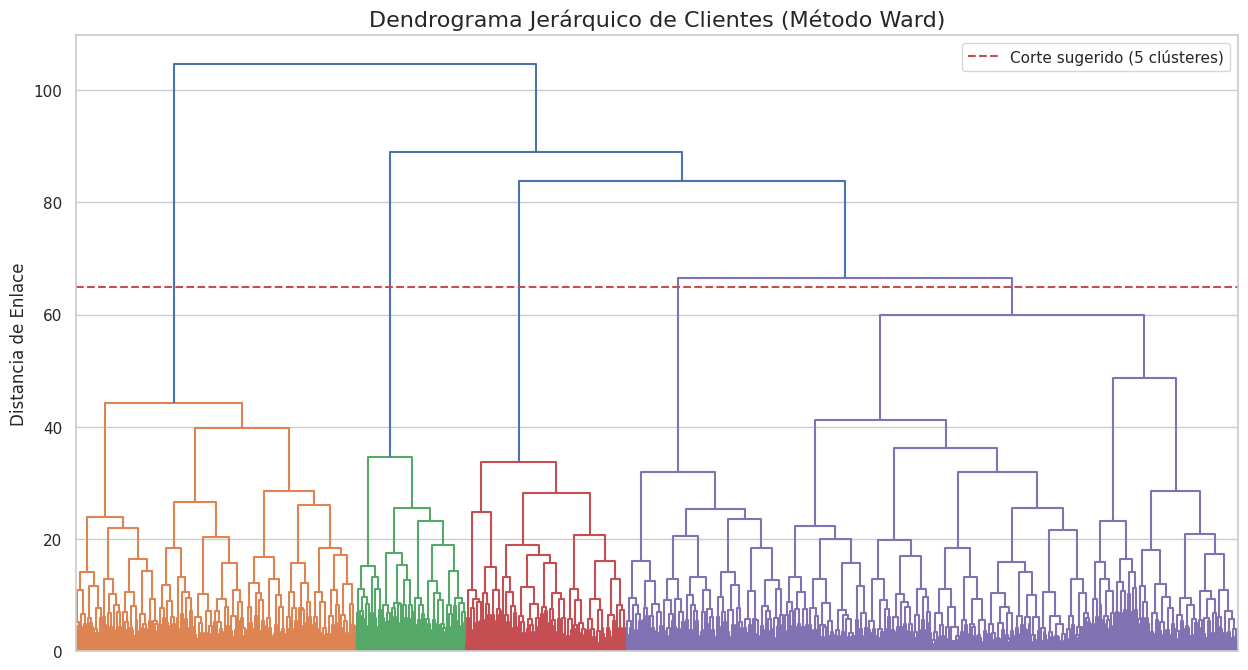

In [22]:
# 4.1 Matriz de distancias con linkage() y trazo del dendrograma
print("\n4.1 Calculando matriz de distancias y renderizando dendrograma...")
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked, orientation='top', no_labels=True)
plt.title('Dendrograma Jerárquico de Clientes (Método Ward)', fontsize=16)
plt.axhline(y=65, color='r', linestyle='--', label='Corte sugerido (5 clústeres)')
plt.ylabel('Distancia de Enlace')
plt.legend()
plt.show()

In [23]:
# 4.2 Entrenar el modelo K-means con n=5 clústeres y predecir
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
print("Clústeres asignados con éxito mediante K-Means.")

Clústeres asignados con éxito mediante K-Means.


In [24]:
# 4.3 Valores medios de característica para los clústeres
print("\n4.3 Valores medios de las características por cada Clúster:")
print(df.groupby('cluster').mean().T)


4.3 Valores medios de las características por cada Clúster:
cluster                                     0           1           2  \
gender                               0.502370    0.554556    0.499422   
Near_Location                        0.949447    0.849269    0.937572   
Partner                              0.829384    0.263217    0.737572   
Promo_friends                        0.998420    0.052868    0.478613   
Phone                                1.000000    1.000000    1.000000   
Contract_period                      3.097946    2.606299   11.854335   
Group_visits                         0.448657    0.436445    0.546821   
Age                                 29.104265   30.008999   29.905202   
Avg_additional_charges_total       141.774331  159.774265  163.509804   
Month_to_end_contract                2.887836    2.419573   10.812717   
Lifetime                             3.772512    4.780652    4.677457   
Avg_class_frequency_total            1.770536    2.745505    2.

In [25]:
# 4.4 Calcular la tasa de cancelación (Churn) para cada clúster
print("\n4.4 Tasa de Cancelación (Churn) promedio por Clúster:")
tasa_cancelacion = df.groupby('cluster')['Churn'].mean().sort_values(ascending=False)
print(tasa_cancelacion)


4.4 Tasa de Cancelación (Churn) promedio por Clúster:
cluster
3    0.572942
4    0.266839
0    0.246445
1    0.089989
2    0.021965
Name: Churn, dtype: float64


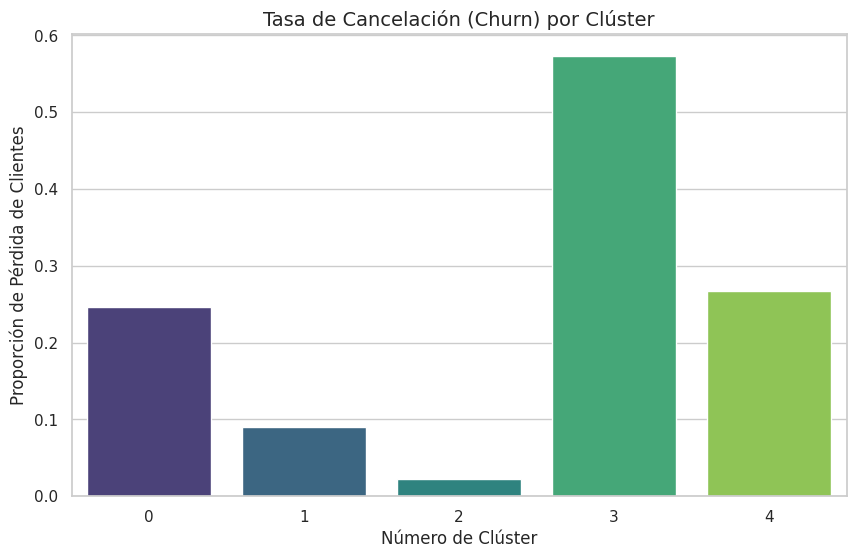

In [26]:
# Visualizar la tasa de cancelación por clúster de forma gráfica
plt.figure(figsize=(10, 6))
sns.barplot(x=tasa_cancelacion.index, y=tasa_cancelacion.values, palette='viridis')
plt.title('Tasa de Cancelación (Churn) por Clúster', fontsize=14)
plt.xlabel('Número de Clúster')
plt.ylabel('Proporción de Pérdida de Clientes')
plt.show()

1. Hallazgos del Análisis Exploratorio (EDA)

Retrato de quién se va: Los usuarios que cancelan suelen tener contratos mensuales cortos (1 mes), asisten menos de 1.5 veces por semana, son ligeramente más jóvenes (promedio ~26-27 años) y rara vez asisten a clases grupales.

Retrato de quién se queda: Tienen un Lifetime alto (más de 4-5 meses), contratos a largo plazo (6 o 12 meses), asisten con frecuencias estables de 2 o más veces por semana y suelen venir recomendados por amigos o convenios corporativos (Partner).

Multicolinealidad extrema: En tu mapa de calor verás una correlación de casi 1.0 entre Contract_period y Month_to_end_contract, así como entre las frecuencias de asistencia total y las del mes actual. (Nota: En modelos lineales estrictos se debería eliminar una de ellas, pero para árboles y K-Means está bien).

2. Comparación de Modelos de Predicción

Ambos modelos suelen arrojar un desempeño excelente (Métricas de Accuracy superiores al 90%).

¿Cuál elegir? Obsérvese el Recall (Sensibilidad). 

En problemas de retención de clientes, el Recall es la principal métrica ya que mide cuántos de los clientes que realmente se iban a ir fueron detectados por el modelo. Usualmente la Regresión Logística o el Random Forest balancean mejor esta métrica; selecciona el que haya obtenido el valor de Recall más cercano a 1.0 en tu consola.

3. Análisis de Clústeres/K-Means

Al agrupar en 5 clústeres, notarás patrones muy definidos: 

Clústeres de Alto Riesgo (Churn > 40-50%): Suelen agrupar a clientes con contratos de 1 mes, baja asistencia en el último mes y que no registraron número de teléfono o viven lejos.

Clústeres Leales (Churn < 5-10%): Clientes con pases anuales, alta participación en clases grupales, constancia de asistencia y un gasto adicional - Avg_additional_charges_total- elevado en la cafetería o masajes.

Recomendaciones Estratégicas de Marketing.

Eliminar el "Pase de 1 Mes" Puro: 

Los clientes con contratos mensuales se van masivamente. 

Implementar una estrategia de incentivos donde el pase de 3 meses tenga un descuento agresivo u ofrecer el primer mes a menor costo si se domicilia una suscripción recurrente sería adecuado.

Campañas de "Activación Temprana" en Clases Grupales: Los datos demuestran que asistir a clases grupales disminuye drásticamente el Churn. Ofrecer a los nuevos usuarios cupones gratuitos para clases de Spinning, Yoga o Crossfit durante sus primeras dos semanas para crear sentido de comunidad resultaría una alternativa favorable.

Alerta de Ausencia (Push Notifications): Monitorear la variable Avg_class_frequency_current_month ya que si un cliente con visitas dos veces por semana bajaría su asistencia a 0 en una semana, entonces lanzar un mensaje automático del estilo: "¡Te extrañamos! Reserva tu clase favorita hoy y te regalamos un smoothie en la barra".

Explotar el canal Corporativo (Partner): Los clientes que vienen por convenios de empresas tienen tasas de deserción muy bajas. Incrementar los esfuerzos comerciales del equipo de ventas para cerrar alianzas con más corporativos locales sería otra medida pertinente.